### `🧠 What is Self-Reflection in RAG?`

Self-Reflection = LLM evaluates its own output: 'Is this clear, complete and accurate?'

Self-Reflection in RAG using LangGraph, will design a workflow where the agent:
1. Generates an initial answer using retrieved context.
2. Reflects on that answer with a dedicated self-critic LLM step
3. If unsatisfied, it can revise the query, retrieve again or regenerate the answer

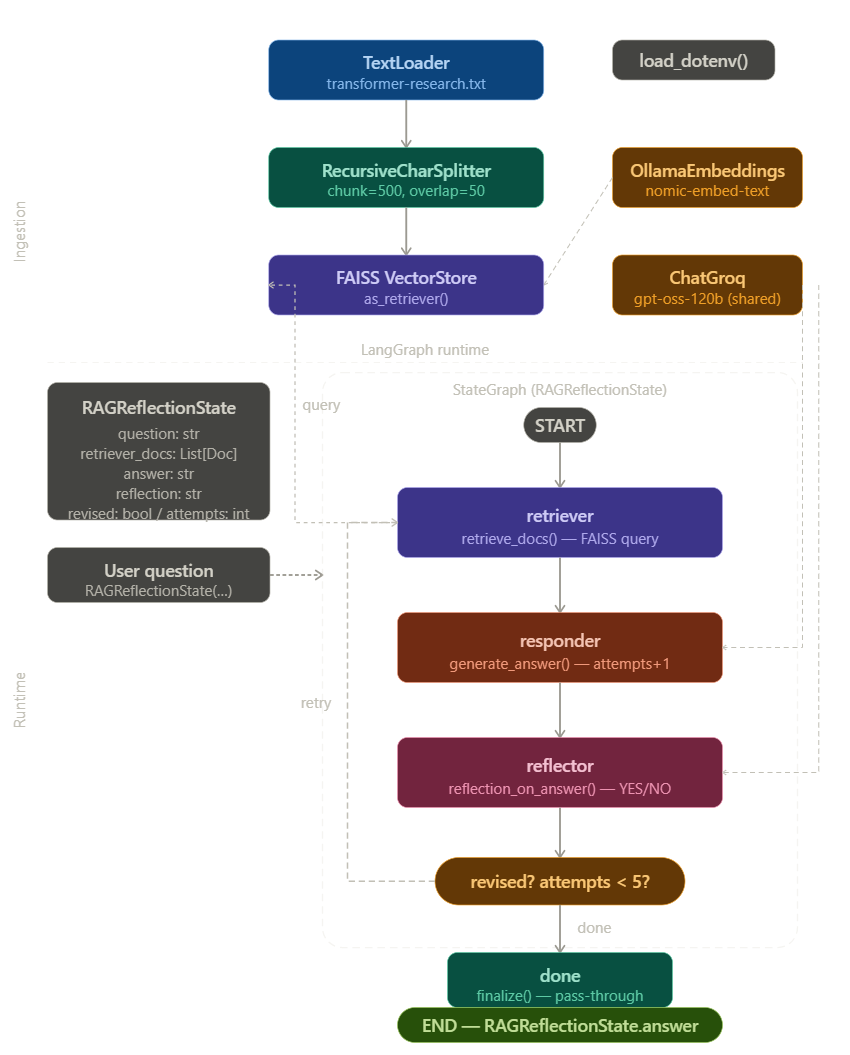

In [1]:
# ------------------------------------------------------------
# 1. Load Text File, Embeddings, Vector Store and LLM 
# ------------------------------------------------------------

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama.embeddings import OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq

import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')

docs = TextLoader('data/transformer-research.txt', encoding='utf-8').load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = text_splitter.split_documents(docs)

embedding = OllamaEmbeddings(model='nomic-embed-text')

vector_store = FAISS.from_documents(chunks, embedding)
retriever = vector_store.as_retriever()

llm = ChatGroq(model='openai/gpt-oss-120b')

In [2]:
# ------------------------------------------------------------
# 2. LangGraph State Definition 
# ------------------------------------------------------------

from typing import List
from pydantic import BaseModel
from langchain_classic.schema import Document

class RAGReflectionState(BaseModel):
    question: str
    retriever_docs: List[Document] = []
    answer: str = ''
    reflection: str = ''
    revised: bool = False
    attempts: int = 0

In [3]:
# ------------------------------------------------------------
# 3. Nodes 
# ------------------------------------------------------------

# a) Retriever Documents
def retrieve_docs(state: RAGReflectionState) -> RAGReflectionState:
    doc = retriever.invoke(state.question)
    return state.model_copy(update={'retriever_docs': doc})

# b) Generate Answer
def generate_answer(state: RAGReflectionState) -> RAGReflectionState:
    context = '\n\n'.join([doc.page_content for doc in state.retriever_docs])
    prompt = f"""
        Use the following context to answer the question:
        
        Context: {context}
        Question: {state.question}
    """
    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={'answer': answer, 'attempts': state.attempts + 1})

# c) Self-Reflection
def reflection_on_answer(state: RAGReflectionState) -> RAGReflectionState:
    prompt = f"""
        Reflect on the following answer to see if it fully address the question.
        State YES if it is complete and correct or NO with an explanation.
        
        Question: {state.question}
        Answer: {state.answer}
    """
    result = llm.invoke(prompt).content
    is_ok = 'reflection: yes' in result.lower()
    return state.model_copy(update={'reflection': result, 'revised': not is_ok})

# d) Finalizer
def finalize(state: RAGReflectionState) -> RAGReflectionState:
    return state

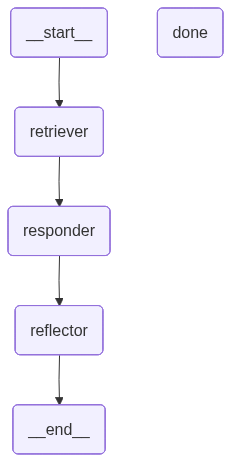

In [4]:
# ------------------------------------------------------------
# 4. LangGraph 
# ------------------------------------------------------------

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(RAGReflectionState)

builder.add_node('retriever', retrieve_docs)
builder.add_node('responder', generate_answer)
builder.add_node('reflector', reflection_on_answer)
builder.add_node('done', finalize)

builder.set_entry_point('retriever')
builder.add_edge('retriever', 'responder')
builder.add_edge('responder', 'reflector')
builder.add_conditional_edges(
    'reflector',
    lambda s: 'done' if not s.revised or s.attempts >= 5 else 'retriever'
)
builder.add_edge('done', END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# ------------------------------------------------------------
# 5. Run the Agent 
# ------------------------------------------------------------

if __name__ == '__main__':
    query = 'What are the transformer variants in production deployments?'
    state = RAGReflectionState(question=query)
    result = graph.invoke(state)
    
    print('\n ✅ Final Answer: \n', result['answer'])
    print('\n 🔃 Reflection Logs: ', result['reflection'])
    print('\n 🔄️ Total Attempts: ', result['attempts'])


 ✅ Final Answer: 
 **Transformer variants that are actually being run in production (according to the experiment log):**

| Variant | Typical use‑case / deployment target | Key production‑relevant facts |
|---------|--------------------------------------|--------------------------------|
| **EfficientFormer** | Edge inference on a **Raspberry Pi 4** (TinyImageNet classification) | 92.4 % top‑1 accuracy, 290 MB peak memory at batch‑size 16, works in **int8‑quantized** mode with negligible accuracy loss. |
| **Longformer** | Processing long‑form **customer‑support logs** (up to 8 k tokens) | Handles very long contexts via chunk‑based hybrid attention; latency ≈ 1.2 s per query in streaming mode. |
| **TinyBERT** | **Support‑ticket priority tagging** (short‑text classification) | 87 % F1, fine‑tuned with a 2‑layer FFN adapter for domain transfer; stable inference footprint. |
| **LLaMA 2** (augmented with **FlashAttention 2**) | Controlled chat / RAG‑augmented conversational agents | Fla